# `Exploratory Data Analysis-[EDA]`

In [ ]:
# Import neccessary libraries for data analysis, manipulation, and visualization.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for plots
plt.style.use('dark_background')  

# Display plots inline in Jupyter Notebook
%matplotlib inline

# Make pandas outptut more readable
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [ ]:
# Load the dataset into a pandas DataFrame

train_df = pd.read_csv('../data/raw/train.csv')
test_df = pd.read_csv('../data/raw/test.csv')
sample_submission_df = pd.read_csv('../data/raw/sample_submission.csv')

In [ ]:
# Display the shape of the datasets to understand the number of rows and columns in each.

print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")
print(f"Sample submission dataset shape: {sample_submission_df.shape}")

In [ ]:
train_df.head()

In [ ]:
test_df.head()

In [ ]:
sample_submission_df.head()

## `Understanding Columns`

In [ ]:
train_df.info()

In [ ]:
# Separate numerical and categorical columns for further analysis.

numerical_cols = train_df.select_dtypes(include="number").columns.tolist()

categorical_cols = ["HomePlanet", "CryoSleep", "Cabin", "Destination", "VIP"]

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

In [ ]:
train_df[numerical_cols].describe()

### `Checking Missing Values`

In [ ]:
# Calculate the number of missing values in each column
train_df.isna().sum().sort_values(ascending=False)

In [ ]:
# Calculate the percentage of missing values in each column
missing_percentage = train_df.isna().mean().sort_values(ascending=False) * 100

In [ ]:
# Optionally, check the type of the missing_percentage variable.
type(missing_percentage)

In [ ]:
# Visualize the missing values using a bar plot to easily identify which features have the most missing data.

plt.figure(figsize=(10, 5))

# missing_percentage[missing_percentage > 0].plot(kind="bar")

plt.bar(missing_percentage[missing_percentage > 0].index, 
        missing_percentage[missing_percentage > 0], 
        color='red', 
        linestyle='--')

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

## `Checking Rows`

In [ ]:
print(f"Number of duplicated rows in train_df: {train_df.duplicated().sum()}")
print(f"Number of duplicated rows in test_df: {test_df.duplicated().sum()}")

## `Analyzing the Target Columns`

In [ ]:
train_df["Transported"].value_counts(normalize=True) * 100

In [ ]:
plt.figure(figsize=(6, 4))

plt.bar(train_df["Transported"].value_counts().index,
        train_df["Transported"].value_counts().values,
        color=['blue', 'orange'],
        alpha=0.7)

plt.title("Distribution of Transported")
plt.xlabel("Transported")
plt.ylabel("Passenger Count")
plt.grid(axis='y', linestyle='--', alpha=0.7, linewidth=0.7, color='gray')

plt.tight_layout()
plt.show()

### `Numerical Feature Investigation`

In [ ]:
# Visualize the distribution of numerical features using histograms to understand their distributions and identify any potential outliers.
train_df[numerical_cols].hist(
    figsize=(12, 8),
    bins=30
)
for ax in plt.gcf().axes:
    for patch in ax.patches:
        patch.set_facecolor("red")
        patch.set_edgecolor("white")
        patch.set_alpha(0.7)

plt.tight_layout()
plt.show()

In [ ]:
# Boxplot to detect outliers in spending features.
plt.figure(figsize=(12, 6))

spending_features = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

sns.boxplot(
    data=train_df[
        spending_features
    ],
)

# Customize the boxplot markers to enhance visibility and aesthetics.
for artist in plt.gca().lines:
    if artist.get_marker() == "o":
        artist.set_markerfacecolor("None")
        artist.set_markeredgecolor("green")
        artist.set_color("red")
        artist.set_markeredgewidth(2)
        artist.set_markersize(8)

plt.title("Spending Feature Distributions")
plt.ylabel("Spending")
plt.tight_layout()
plt.show()

### `Categorical Feature Investigation`

In [ ]:
categorical_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

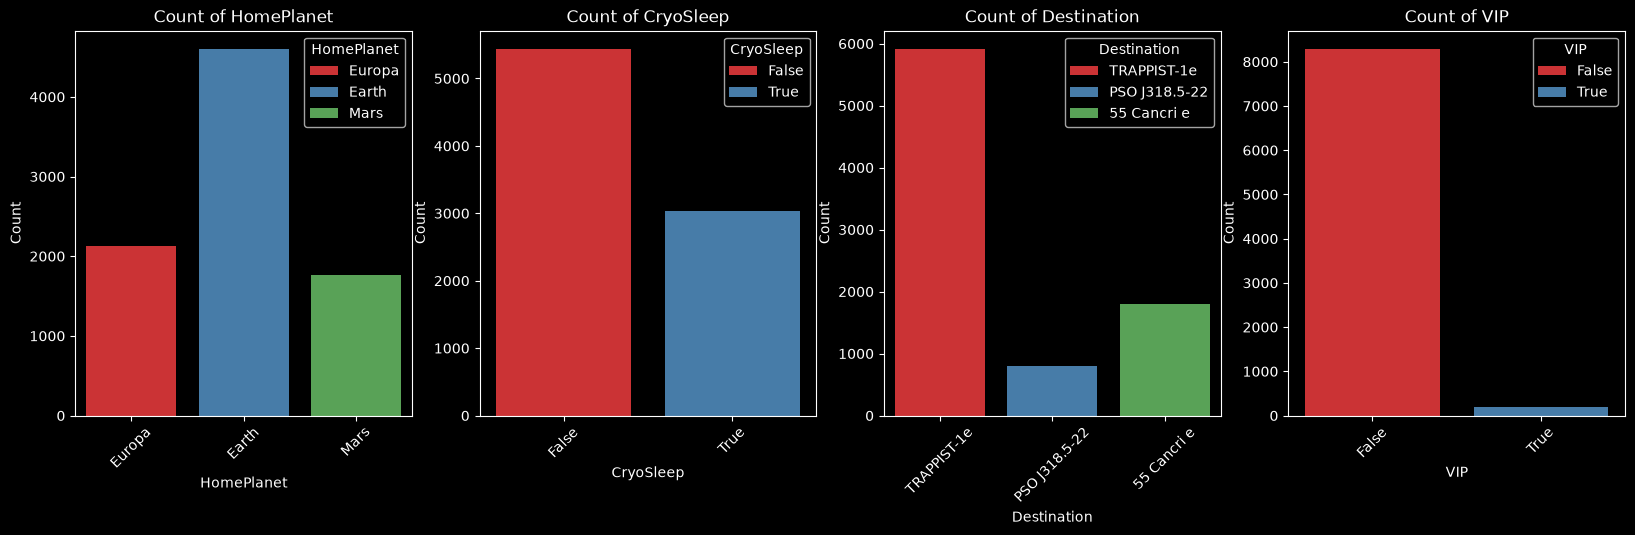

In [98]:
# Visualize the distribution of each categorical feature using count plots.

fig, ax = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=train_df,
        x=col,
        ax=ax[i],
        palette="Set1",
        hue = col
    )

    ax[i].set_title(f"Count of {col}")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Count")
    ax[i].tick_params(axis="x", rotation=45)

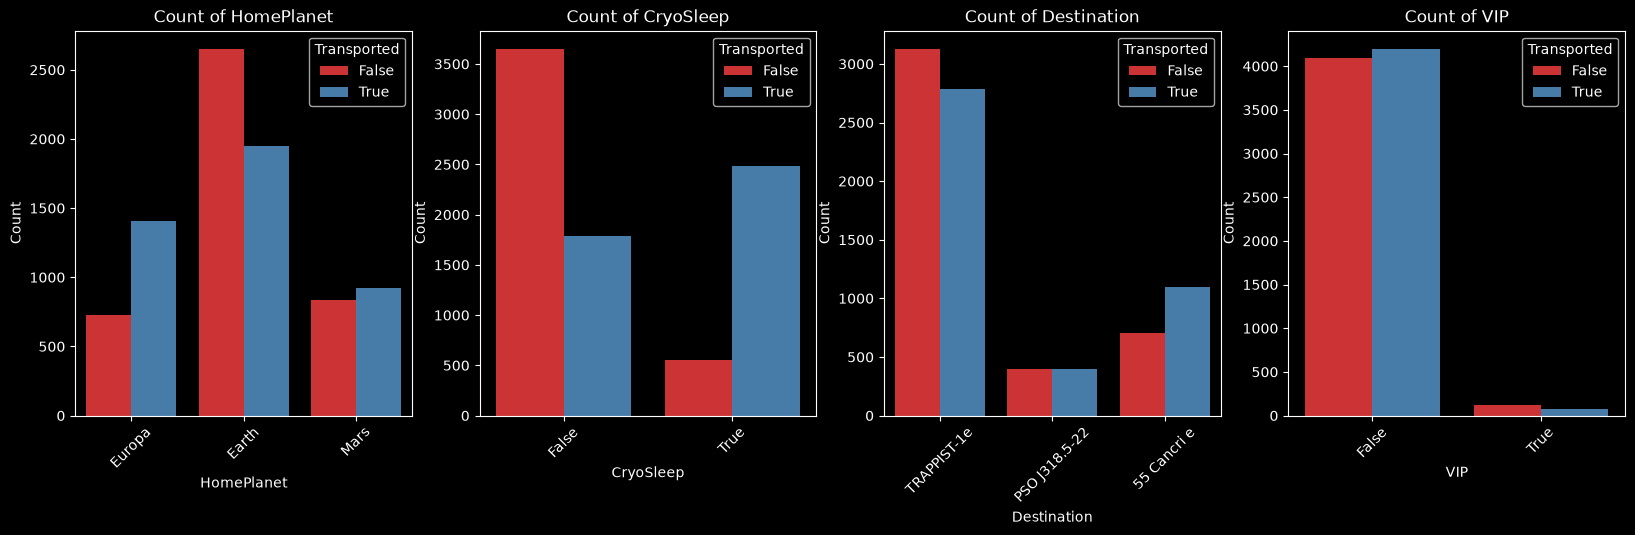

In [101]:
# Visualize the count of categorical features with respect to the target variable "Transported".
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(categorical_cols):
    sns.countplot(data=train_df, 
                    x=col, 
                    ax=ax[i], 
                    hue="Transported",
                    palette="Set1")
                    
    ax[i].set_title(f"Count of {col}")
    ax[i].set_xlabel(col)
    ax[i].set_ylabel("Count")
    ax[i].tick_params(axis='x', rotation=45)

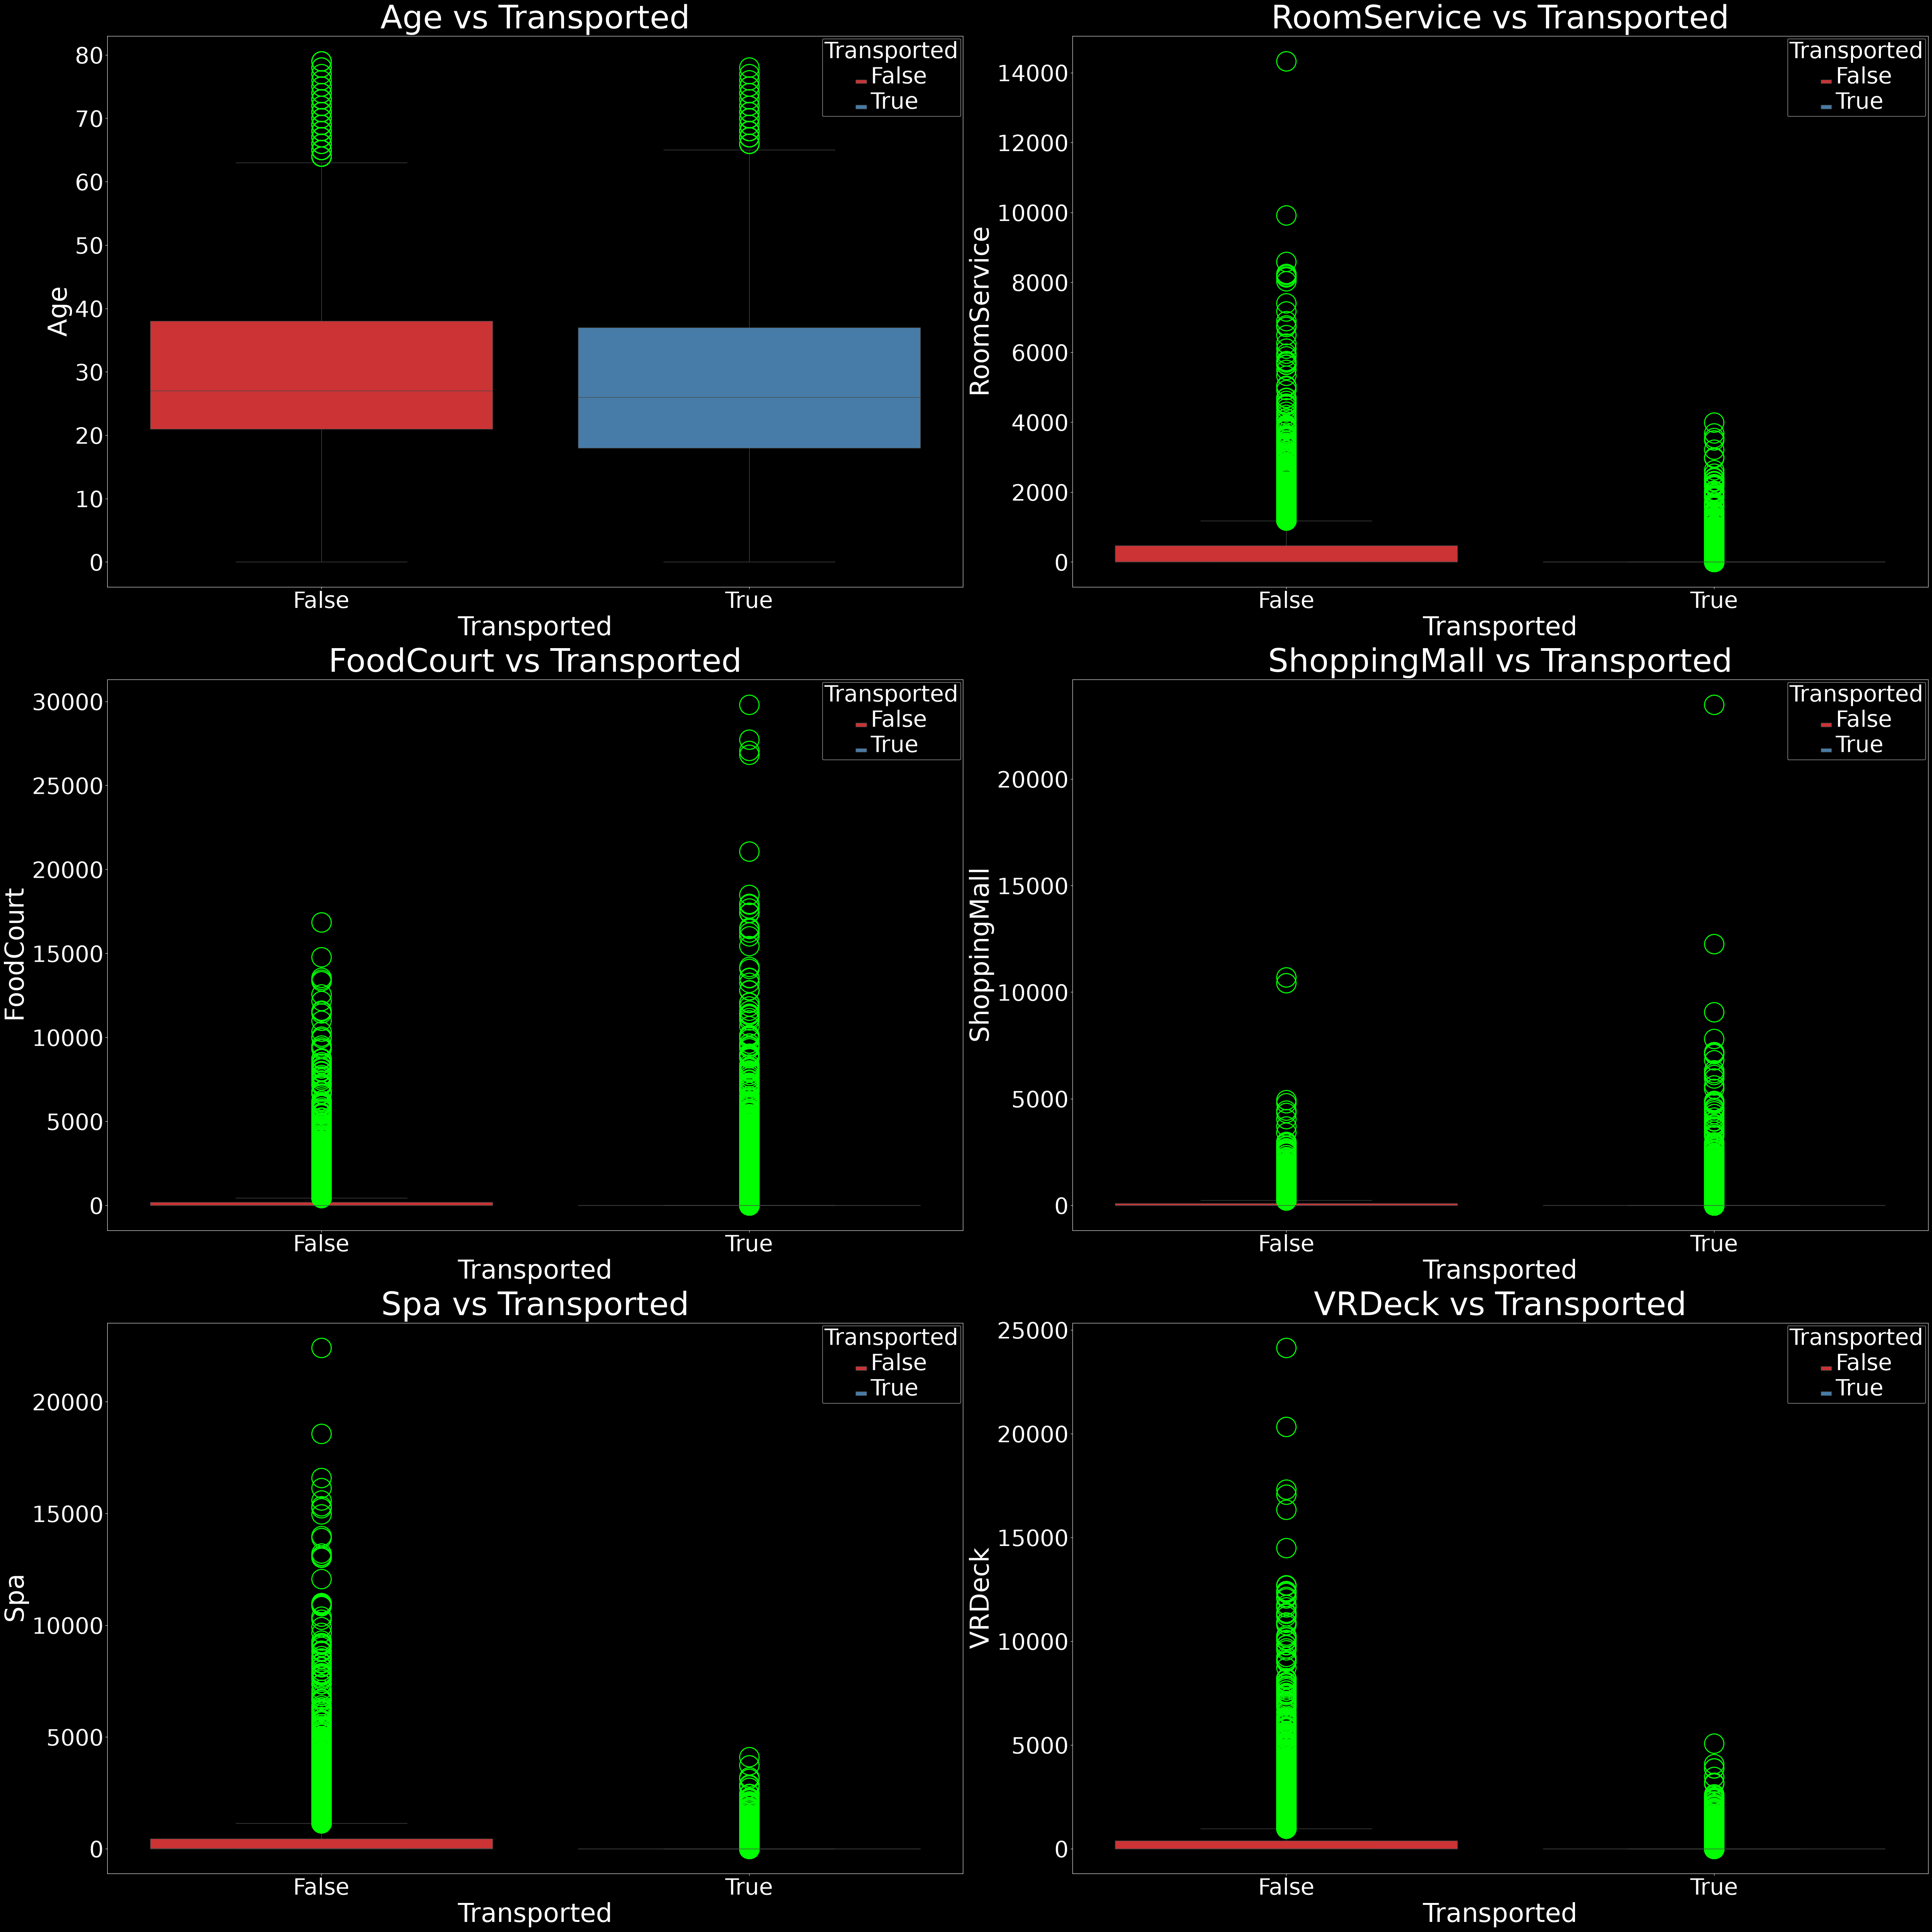

In [110]:
# Adjustable text and marker sizes
# Multiplication parameter for all plot sizes
size_multiplier = 3

s = {
    "title_size": int(20 * size_multiplier),
    "label_size": int(16 * size_multiplier),
    "tick_size": int(14 * size_multiplier),
    "legend_size": int(14 * size_multiplier),
    "outlier_size": int(12 * size_multiplier)
}


fig, ax = plt.subplots(3, 2, figsize=(50, 50))

for i, col in enumerate(numerical_cols):
    current_ax = ax.flat[i]

    sns.boxplot(
        data=train_df,
        x="Transported",
        y=col,
        hue="Transported",
        ax=current_ax,
        palette="Set1",
        legend=True,
        flierprops={
            "marker": "o",
            "markersize": s["outlier_size"],
            "markerfacecolor": "none",
            "markeredgecolor": "lime",
            "markeredgewidth": 2
        }
    )

    current_ax.set_title(f"{col} vs Transported", fontsize=s["title_size"])
    current_ax.set_xlabel("Transported", fontsize=s["label_size"])
    current_ax.set_ylabel(col, fontsize=s["label_size"])
    current_ax.tick_params(axis="both", labelsize=s["tick_size"])

    legend = current_ax.get_legend()
    if legend:
        for text in legend.get_texts():
            text.set_fontsize(s["legend_size"])
        legend.get_title().set_fontsize(s["legend_size"])

plt.tight_layout()
plt.show()

### `Correlation Analysis`

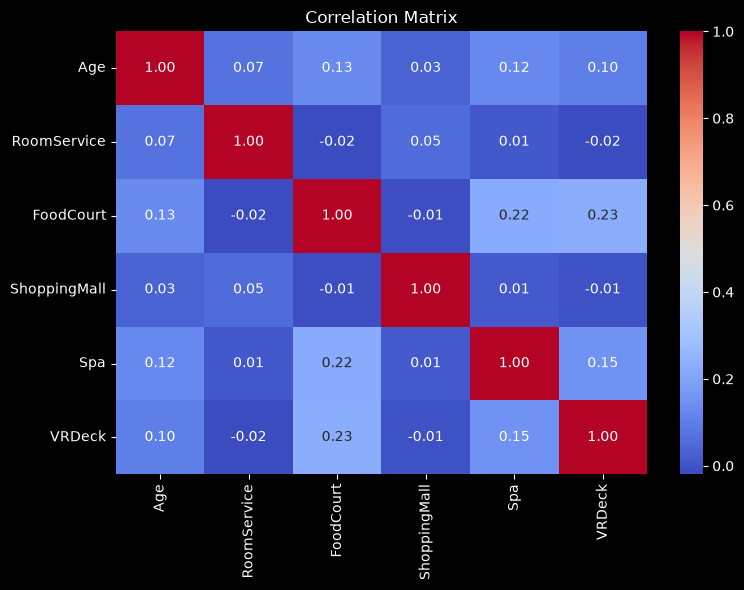

In [116]:
correlation_matrix = train_df[numerical_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## EDA Conclusions

### Dataset
- Training set contains 8,693 passengers.
- Test set contains 4,277 passengers.
- Target variable is `Transported`.

### Missing Values
- Several features contain missing values.
- Missing-value handling will be required during preprocessing.

### Numerical Features
- `Age` is numerical.
- Spending features contain many zero values and are highly skewed.
- Some extreme spending values exist.

### Categorical Features
- `HomePlanet`, `CryoSleep`, `Destination`, and `VIP` contain categorical information.
- These features show different relationships with `Transported`.

### Feature Engineering Opportunities
- `Cabin` can be decomposed into `Deck`, `CabinNumber`, and `CabinSide`.
- `PassengerId` contains group-related information.
- `Name` may contain family-related information.

### Next Step
The next notebook will focus on feature engineering and preprocessing.